# Langkah 1: Memuat Dataset


Pada langkah pertama ini, kita akan memuat dataset dummy yang berisi informasi terkait pembelian pelanggan,
seperti usia, jumlah pembelian, jumlah diskon yang pernah diterima, dan apakah pelanggan merespons kampanye diskon sebelumnya.


In [ ]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_excel('20_deteksi_produk_populer.xlsx')
df

,Customer ID,Age,Total Purchases (IDR),Discount Amount (IDR),Response to Last Campaign,Successful Discount Campaign
0,1,19,4174999,40282,1,1
1,2,19,763431,172809,1,1
2,3,32,677701,495643,1,0
3,4,40,1688404,291268,1,1
4,5,46,1905148,337246,1,0
...,...,...,...,...,...,...
295,296,37,1014217,208990,1,0
296,297,33,3964708,450899,1,0
297,298,34,4926176,262481,1,1
298,299,33,178113,5801,1,1


# Langkah 2: Visualisasi Data


Kita akan membuat visualisasi untuk memahami pola data, seperti distribusi keberhasilan kampanye diskon
dan hubungan antara jumlah pembelian dengan jumlah diskon yang diberikan.


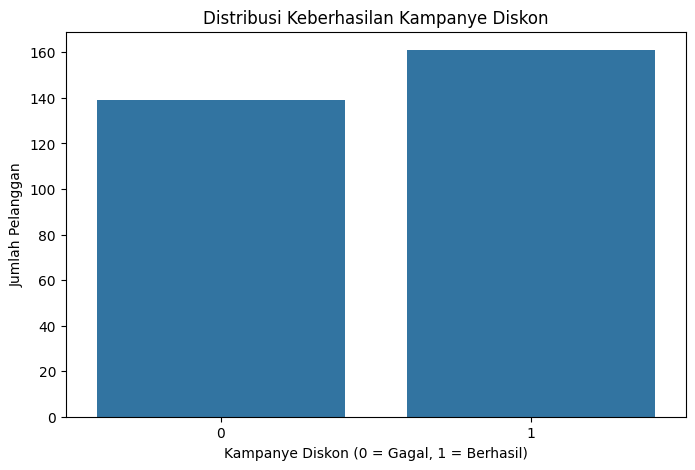

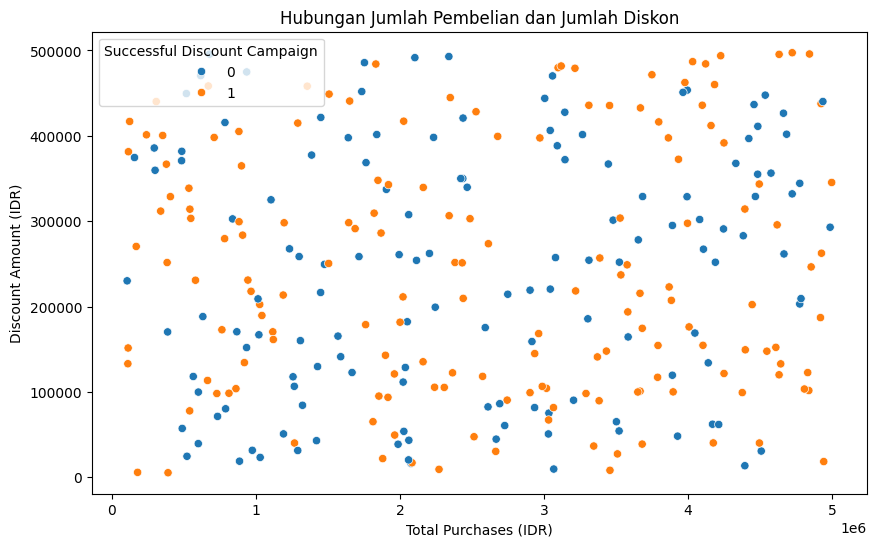

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

# Visualisasi distribusi keberhasilan kampanye diskon
plt.figure(figsize=(8, 5))
sns.countplot(x='Successful Discount Campaign', data=df)
plt.title('Distribusi Keberhasilan Kampanye Diskon')
plt.xlabel('Kampanye Diskon (0 = Gagal, 1 = Berhasil)')
plt.ylabel('Jumlah Pelanggan')
plt.show()

# Hubungan antara jumlah pembelian dan jumlah diskon
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Total Purchases (IDR)', y='Discount Amount (IDR)', hue='Successful Discount Campaign', data=df)
plt.title('Hubungan Jumlah Pembelian dan Jumlah Diskon')
plt.show()


# Langkah 3: Preprocessing Data


Di tahap ini, kita akan memilih fitur-fitur yang akan digunakan untuk memprediksi keberhasilan kampanye diskon,
yaitu usia pelanggan, jumlah pembelian, jumlah diskon yang diterima, dan respons terhadap kampanye sebelumnya.


In [ ]:

# Memilih fitur dan target
X = df[['Age', 'Total Purchases (IDR)', 'Discount Amount (IDR)', 'Response to Last Campaign']]
y = df['Successful Discount Campaign']


# Langkah 4: Normalisasi Data


Karena skala fitur bervariasi, kita akan melakukan normalisasi menggunakan StandardScaler
agar model machine learning bekerja lebih optimal.


In [ ]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# Langkah 5: Membagi Data Train dan Test


Data akan dibagi menjadi data latih (train) dan data uji (test) dengan rasio 70:30
untuk melatih model dan menguji performanya.


In [ ]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)


# Langkah 6: Melatih Model


Kita akan menggunakan Random Forest Classifier sebagai model machine learning untuk memprediksi keberhasilan kampanye diskon.


In [ ]:

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

# Langkah 7: Evaluasi Model


Langkah evaluasi bertujuan untuk mengukur performa model menggunakan metrik seperti akurasi, confusion matrix,
dan classification report.


In [ ]:

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred = model.predict(X_test)
print("Akurasi Model:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))


Akurasi Model: 0.6333333333333333
Confusion Matrix:
[[22 22]
 [11 35]]
Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.50      0.57        44
           1       0.61      0.76      0.68        46

    accuracy                           0.63        90
   macro avg       0.64      0.63      0.63        90
weighted avg       0.64      0.63      0.63        90



# Langkah 8: Prediksi


Kita akan mencoba memprediksi apakah kampanye diskon akan berhasil berdasarkan contoh data pelanggan baru.


In [ ]:

# Contoh prediksi untuk pelanggan baru
sample_data = np.array([[30, 1500000, 100000, 1]])
sample_data_scaled = scaler.transform(sample_data)
prediction = model.predict(sample_data_scaled)
print("Prediksi Keberhasilan Kampanye Diskon (0 = Gagal, 1 = Berhasil):", prediction[0])


Prediksi Keberhasilan Kampanye Diskon (0 = Gagal, 1 = Berhasil): 1


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(



## Keterangan Penting

Notebook ini menggunakan data dummy. Agar model ini dapat menghasilkan prediksi yang lebih akurat dan relevan, **kustomisasi lebih lanjut diperlukan**. Beberapa hal yang perlu dipertimbangkan antara lain:

1. **Penyempurnaan Dataset**: Data yang digunakan adalah data dummy yang bersifat acak. Untuk hasil yang lebih baik, dataset harus diisi dengan data kemacetan lalu lintas yang lebih realistis dan sesuai dengan kondisi lokal yang relevan.
   
2. **Penyesuaian Fitur**: Beberapa fitur, seperti jumlah kendaraan, kecepatan rata-rata, atau status sinyal lalu lintas, perlu penyesuaian atau penambahan fitur lain yang lebih berdampak pada prediksi kemacetan.

3. **Parameter Model**: Untuk hasil prediksi yang lebih optimal, Anda dapat menyesuaikan parameter model SVM atau mencoba model lain yang lebih sesuai dengan karakteristik data.

4. **Validasi Model**: Melakukan validasi dengan data nyata dan cross-validation untuk mengevaluasi kinerja model.

Dengan penyesuaian yang tepat, model ini dapat memberikan prediksi kemacetan yang lebih akurat dan bermanfaat untuk mengatur lalu lintas di kota dan meningkatkan mobilitas perkotaan.
